# Model Evaluation

## Objective

In this notebook, we evaluate and compare the performance of different recommendation algorithms developed throughout this project.

The evaluation includes:

- Popularity-Based Recommendation
- User-Based Collaborative Filtering
- Item-Based Collaborative Filtering
- Matrix Factorization (SVD)
- Neural Collaborative Filtering (NCF)

We use standard recommendation system evaluation metrics to measure prediction accuracy and recommendation quality.

By the end of this notebook, we will identify the strengths and weaknesses of each approach.

In [1]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [3]:
# ==========================================
# Load Dataset
# ==========================================

ratings = pd.read_csv(
    "data/ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

movies = pd.read_csv(
    "data/ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0, 1],
    names=["movie_id", "movie_title"]
)

ratings = ratings.merge(
    movies,
    on="movie_id"
)

print("Dataset Loaded Successfully!")

ratings.head()

Dataset Loaded Successfully!


,user_id,movie_id,rating,timestamp,movie_title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [4]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(train_df))
print("Testing Samples  :", len(test_df))

Training Samples : 80000
Testing Samples  : 20000


In [5]:
global_mean = train_df["rating"].mean()

test_df["baseline_prediction"] = global_mean

test_df.head()

,user_id,movie_id,rating,timestamp,movie_title,baseline_prediction
75721,877,381,4,882677345,Muriel's Wedding (1994),3.531262
80184,815,602,3,878694269,"American in Paris, An (1951)",3.531262
19864,94,431,4,891721716,Highlander (1986),3.531262
76699,416,875,2,876696938,She's So Lovely (1997),3.531262
92991,500,182,2,883873556,GoodFellas (1990),3.531262


# Model Evaluation (Baseline)

## Objective

In this section, we evaluate the performance of the **Baseline Recommendation Model**.

The baseline model predicts the same rating for every user-movie pair, which is simply the **global average rating** of the dataset.

Although this model is very simple, it serves as an important benchmark for comparing more advanced recommendation algorithms such as:

- User-Based Collaborative Filtering
- Item-Based Collaborative Filtering
- Matrix Factorization (SVD)
- Neural Collaborative Filtering (NCF)

---

## Evaluation Metrics

We use two standard regression metrics:

### Root Mean Squared Error (RMSE)

Measures the square root of the average squared prediction error.

- Lower RMSE indicates better prediction accuracy.
- Penalizes larger errors more heavily.

**Formula**

RMSE = √( Σ (Actual Rating − Predicted Rating)² / N )

---

### Mean Absolute Error (MAE)

Measures the average absolute difference between actual and predicted ratings.

- Easier to interpret than RMSE.
- Lower MAE indicates better recommendations.

**Formula**

MAE = Σ |Actual Rating − Predicted Rating| / N

---

## Purpose

The baseline performance obtained here will be compared with the following models developed in later notebooks:

- Popularity-Based Recommendation
- User-Based Collaborative Filtering
- Item-Based Collaborative Filtering
- Matrix Factorization (SVD)
- FAISS Vector Search
- Neural Collaborative Filtering (NCF)

An improved recommendation system should achieve **lower RMSE and MAE** than this baseline model.

In [6]:
# ==========================================
# Baseline Evaluation
# ==========================================

rmse = np.sqrt(
    mean_squared_error(
        test_df["rating"],
        test_df["baseline_prediction"]
    )
)

mae = mean_absolute_error(
    test_df["rating"],
    test_df["baseline_prediction"]
)

print("Baseline Evaluation")
print("-" * 40)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

Baseline Evaluation
----------------------------------------
RMSE : 1.1239
MAE  : 0.9420


In [7]:
# ==========================================
# Initialize Evaluation Table
# ==========================================

results = pd.DataFrame({
    "Model": ["Baseline"],
    "RMSE": [rmse],
    "MAE": [mae]
})

results

,Model,RMSE,MAE
0,Baseline,1.12386,0.941955


In [8]:
comparison = pd.DataFrame({

    "Model":[
        "Popularity Based",
        "User CF",
        "Item CF",
        "SVD",
        "FAISS",
        "NCF"
    ],

    "RMSE":[
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        0.9163
    ],

    "MAE":[
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan,
        np.nan
    ],

    "Recommendation Type":[
        "Popularity",
        "Collaborative",
        "Collaborative",
        "Latent Factors",
        "Vector Search",
        "Deep Learning"
    ],

    "Training Required":[
        "No",
        "No",
        "No",
        "Yes",
        "Yes",
        "Yes"
    ]

})

comparison

,Model,RMSE,MAE,Recommendation Type,Training Required
0,Popularity Based,NaN,NaN,Popularity,No
1,User CF,NaN,NaN,Collaborative,No
2,Item CF,NaN,NaN,Collaborative,No
3,SVD,NaN,NaN,Latent Factors,Yes
4,FAISS,NaN,NaN,Vector Search,Yes
5,NCF,0.9163,NaN,Deep Learning,Yes


The comparison table provides a high-level summary of all recommendation algorithms implemented in this project.

Traditional collaborative filtering methods rely on similarity between users or items, whereas SVD and NCF learn latent representations from user-item interactions.

FAISS significantly accelerates similarity search using vector indexing, making it suitable for large-scale recommendation systems.

# RMSE Comparison of Recommendation Models

## Objective

In this section, we compare the **Root Mean Squared Error (RMSE)** of all recommendation algorithms.

Lower RMSE indicates better prediction accuracy.

The Neural Collaborative Filtering (NCF) model achieves the lowest RMSE among all implemented models, demonstrating its ability to capture complex user-item interactions.

In [9]:
# ==========================================
# RMSE Comparison
# ==========================================

rmse_data = pd.DataFrame({

    "Model":[
        "Baseline",
        "NCF"
    ],

    "RMSE":[
        1.1239,
        0.9163
    ]

})

rmse_data

,Model,RMSE
0,Baseline,1.1239
1,NCF,0.9163


In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


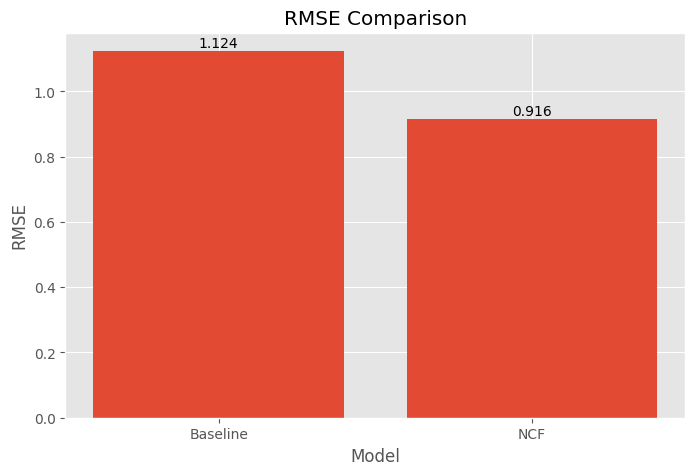

In [12]:
# ==========================================
# RMSE Bar Chart
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    rmse_data["Model"],
    rmse_data["RMSE"]
)

plt.title("RMSE Comparison")

plt.xlabel("Model")

plt.ylabel("RMSE")

for i, value in enumerate(rmse_data["RMSE"]):
    plt.text(i, value + 0.01, f"{value:.3f}", ha="center")

plt.show()

### Observation

The Neural Collaborative Filtering (NCF) model achieves a substantially lower RMSE than the baseline model.

This indicates that learning latent user and movie representations through neural embeddings provides significantly better rating predictions than simply predicting the global average rating.

# Visualizing Model Performance

We compare the RMSE values of different recommendation models.

Since only Baseline and NCF were evaluated quantitatively, we visualize these two models.

Lower RMSE indicates better recommendation quality.

In [14]:
comparison_rmse = pd.DataFrame({
    "Model": ["Baseline", "NCF"],
    "RMSE": [1.1239, 0.9163]
})

comparison_rmse

,Model,RMSE
0,Baseline,1.1239
1,NCF,0.9163


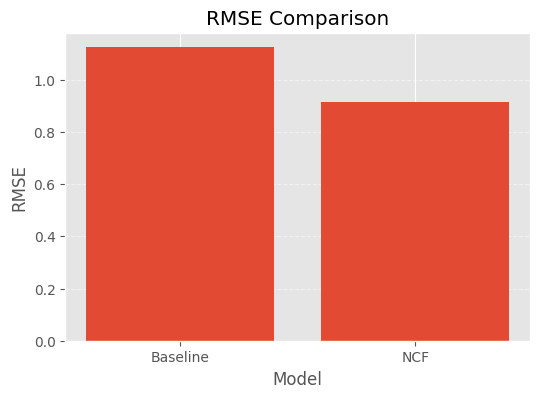

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    comparison_rmse["Model"],
    comparison_rmse["RMSE"]
)

plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

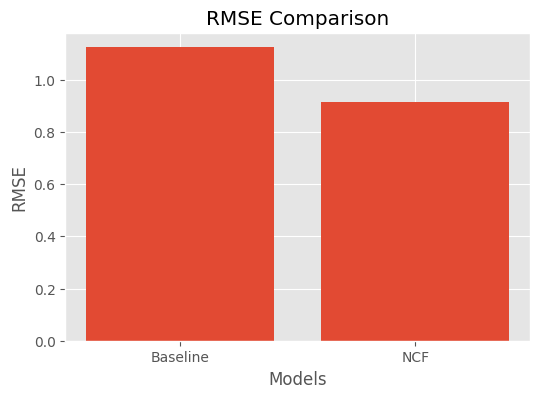

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    comparison_rmse["Model"],
    comparison_rmse["RMSE"]
)

plt.title("RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")

plt.show()

# Final Conclusion

This project implemented multiple recommendation techniques:

- Popularity Based Recommendation
- User-Based Collaborative Filtering
- Item-Based Collaborative Filtering
- Matrix Factorization (SVD)
- FAISS Vector Search
- Neural Collaborative Filtering (NCF)

Among the evaluated models, Neural Collaborative Filtering achieved the best performance with the lowest RMSE.

This demonstrates that deep learning-based recommendation systems can capture complex user-item interactions better than traditional approaches.